# Fantasy Football Hierarchical Bayesian Inference

## Imports

In [1]:
import math
import nfldb
import matplotlib.pyplot as plt
from pylab import rcParams
%matplotlib inline
%config InlineBackend.figure_format = 'png'
import seaborn as sns
import numpy as np
import pandas as pd
import theano.tensor as tt
import pymc3 as pm
from IPython.core.debugger import Tracer

## Data Import and Munging

### nfldb
Create data base with passing yards for the 2015 regular season with nfldb

In [2]:
# selftart up nfldb
db = nfldb.connect()
q = nfldb.Query(db)
season_year = 2015
season_type = 'Regular'
# play id
q.game(season_year=season_year, season_type=season_type)
# plays = g.as_plays()

# initialize
home_team = []
away_team = []
gamekey   = []
home_yds = []
away_yds = []
week = []
num_games = 0

# loop through games
for i in range(1,18):
    # find out who plays who
    q = nfldb.Query(db).game(season_year=season_year,season_type=season_type,week=i)
    for g in q.as_games():
        home_team.append(g.home_team)
        away_team.append(g.away_team)
        gamekey.append(g.gamekey)
        week.append(i)
        num_games += 1

# cycle through each playplayer for yards
for i in range(0, num_games):
    # home team yards
    q = nfldb.Query(db).game(gamekey=gamekey[i],team=home_team[i])
    q.play_player(team=home_team[i])
    pps = q.as_aggregate()
    home_yds.append(sum(pp.passing_yds for pp in pps))
          
    # away team yards
    q = nfldb.Query(db).game(gamekey=gamekey[i],team=away_team[i])
    q.play_player(team=away_team[i])
    pps = q.as_aggregate()
    away_yds.append(sum(pp.passing_yds for pp in pps))

# save to a new dataframe
df = pd.DataFrame({'home_team':home_team,
                   'away_team':away_team,
                   'home_yds':home_yds,
                   'away_yds':away_yds,
                   'week':week,
                   'gamekey':gamekey})

### Munging
Create a look-up table for team names

In [3]:
teams = df.home_team.unique()
teams = pd.DataFrame(teams, columns=['team'])
teams['i'] = teams.index
teams.head()
teams.to_csv('teams.csv')

Create away and home columns

In [4]:
df = pd.merge(df, teams, left_on='home_team', right_on='team', how='left')
df = df.rename(columns = {'i': 'i_home'}).drop('team', 1)
df = pd.merge(df, teams, left_on='away_team', right_on='team', how='left')
df = df.rename(columns = {'i': 'i_away'}).drop('team', 1)
num_teams = len(df.i_home.drop_duplicates())
df.to_csv('out.csv')
df.head()

  away_team  away_yds gamekey home_team  home_yds  week  i_home  i_away
0       TEN       209   56515        TB       210     1       0      29
1       BAL       117   56513       DEN       175     1       1      28
2       DET       246   56512        SD       404     1       2      27
3       IND       243   56504       BUF       195     1       3      20
4        KC       243   56506       HOU       334     1       4      21

## Modeling
### Priors

In [8]:
model = pm.Model()
with pm.Model() as model:
    # global model parameters
    home       = pm.Normal('home',      0, tau=.0001)
    tau_att    = pm.Gamma('tau_att',   .1, .1)
    tau_def    = pm.Gamma('tau_def',   .1, .1)
    intercept  = pm.Normal('intercept', 0, tau=.0001)
    #team-specific parameters
    atts_star  = pm.Normal('atts_star',
                           mu    = 0,
                           tau   = tau_att,
                           shape = num_teams)
    defs_star  = pm.Normal('defs_star',
                           mu    = 0,
                           tau   = tau_def,
                           shape = num_teams)

In [0]:
### Constraints

In [9]:
with model:
    atts       = pm.Deterministic('atts', atts_star - tt.mean(atts_star))
    defs       = pm.Deterministic('defs', defs_star - tt.mean(defs_star))
    home_theta = tt.exp(intercept + home + atts[df.i_home.values] + defs[df.i_away.values])
    away_theta = tt.exp(intercept + atts[df.i_away.values] + defs[df.i_home.values])

### Update beleifs with observations

In [10]:
with model:
    # likelihood of observed data
    home_yds = pm.Poisson('home_yds',
                          mu=home_theta,
                          observed=df.home_yds.values)
    away_yds = pm.Poisson('away_yds',
                          mu=away_theta,
                          observed=df.away_yds.values)

## Sampling

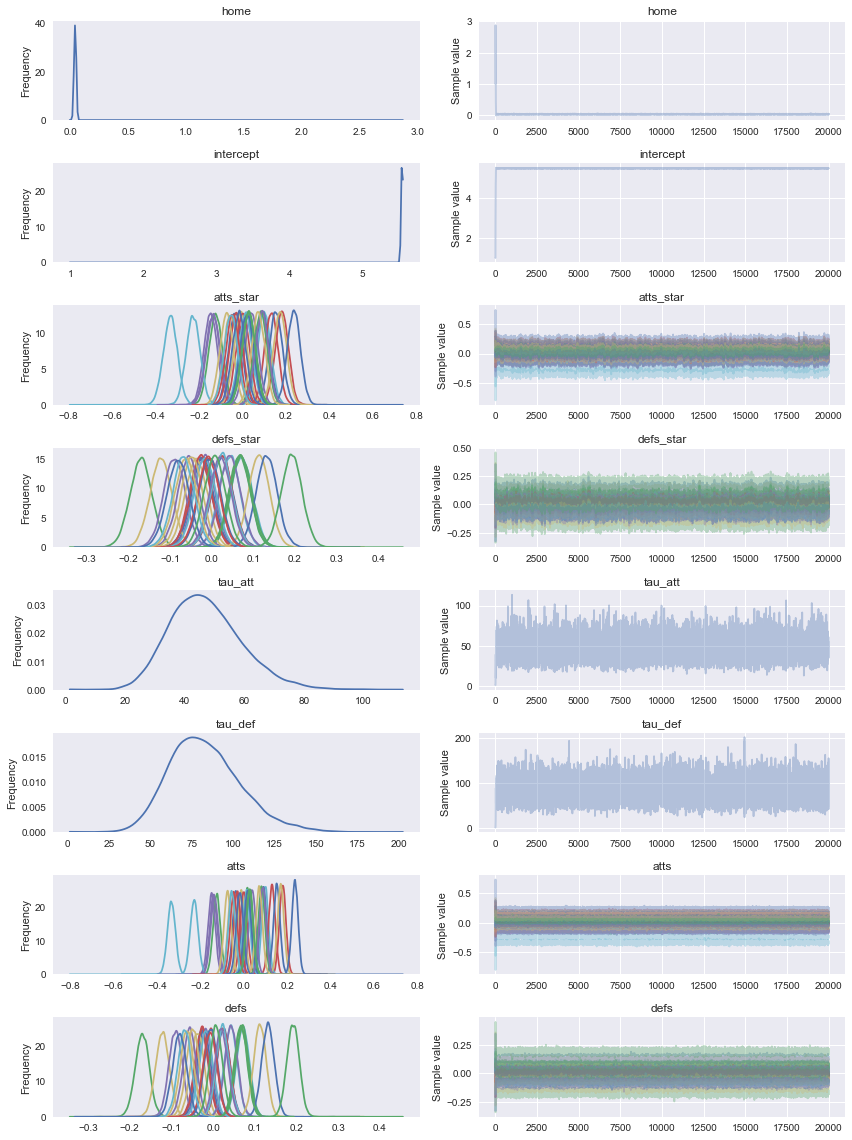

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x119b1c0d0>,
        <matplotlib.axes._subplots.AxesSubplot object at 0x11c56a2d0>]], dtype=object)

100%|██████████| 20000/20000 [00:49<00:00, 402.20it/s]

100%|█████████▉| 19956/20000 [00:49<00:00, 464.77it/s]

100%|█████████▉| 19905/20000 [00:49<00:00, 448.92it/s]

 99%|█████████▉| 19858/20000 [00:49<00:00, 440.55it/s]

...

  0%|          | 40/20000 [00:00<02:54, 114.12it/s]

  0%|          | 32/20000 [00:00<02:06, 158.17it/s]

  0%|          | 20/20000 [00:00<01:40, 199.54it/s]

  0%|          | 0/20000 [00:00<?, ?it/s]

Optimization terminated successfully.
         Current function value: 5906.599874
         Iterations: 97
         Function evaluations: 234
         Gradient evaluations: 230


In [11]:
with model:
    start = pm.find_MAP()
    step = pm.NUTS(state=start)
    trace = pm.sample(20000,step,init=start)
pm.traceplot(trace)

In [0]:
## Results
### Convergence

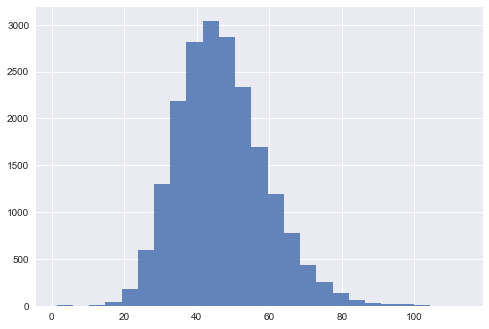

(array([  6.00000000e+00,   3.00000000e+00,   6.00000000e+00,
          3.70000000e+01,   1.78000000e+02,   5.93000000e+02,
          1.30000000e+03,   2.18300000e+03,   2.82000000e+03,
          3.03900000e+03,   2.86800000e+03,   2.33900000e+03,
          1.69400000e+03,   1.19300000e+03,   7.77000000e+02,
          4.36000000e+02,   2.58000000e+02,   1.37000000e+02,
          5.90000000e+01,   3.40000000e+01,   1.70000000e+01,
          1.40000000e+01,   6.00000000e+00,   2.00000000e+00,
          1.00000000e+00]),
 array([   1.37115364,    5.84747647,   10.3237993 ,   14.80012214,
          19.27644497,   23.7527678 ,   28.22909063,   32.70541346,
          37.18173629,   41.65805912,   46.13438195,   50.61070478,
          55.08702761,   59.56335045,   64.03967328,   68.51599611,
          72.99231894,   77.46864177,   81.9449646 ,   86.42128743,
          90.89761026,   95.37393309,   99.85025592,  104.32657875,
         108.80290159,  113.27922442]),
 <a list of 1 Patch objects>

In [12]:
plt.hist(trace['tau_att'], histtype='stepfilled', bins=25, alpha=0.85)

### Confidence Intervals

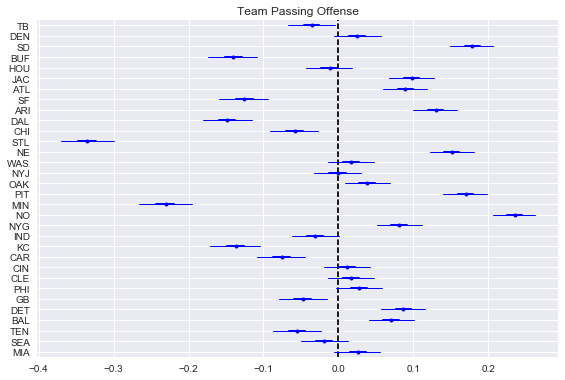

In [13]:
pm.forestplot(trace, varnames=['atts'], ylabels=teams['team'], main="Team Passing Offense")

### Defense strength

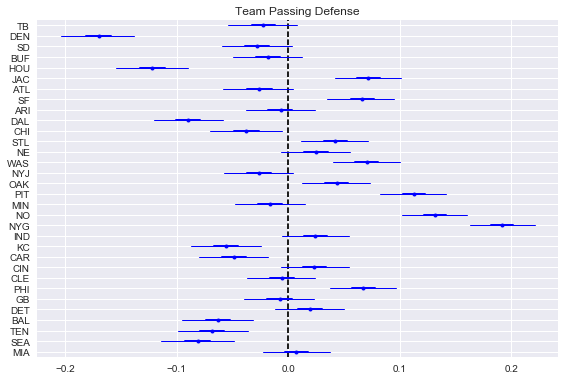

In [14]:
pm.forestplot(trace, varnames=['defs'], ylabels=teams['team'], main="Team Passing Defense")

# Simulation
## Define simulation

In [18]:
def simulate_team_seasons(team, n):
    dfs = []
    i_team = teams[teams['team']==team]['i'].values[0]
    games = df[(df['i_home']==i_team) | (df['i_away']==i_team)]
    for i in range(n):
        season = simulate_team_season(i_team, games)
        t = create_team_season_table(i_team, season)
        t['iteration'] = i
        dfs.append(t)
    return pd.concat(dfs, ignore_index=True)
    
def simulate_team_season(i_team, games):
    num_samples = trace['atts'].shape[0]
    draw = np.random.randint(0, num_samples)
    atts_draw = pd.DataFrame({'att': trace['atts'][draw, :],})
    defs_draw = pd.DataFrame({'def': trace['defs'][draw, :],})
    home_draw = trace['home'][draw]
    intercept_draw = trace['intercept'][draw]

    season = games.copy()
    season = pd.merge(season, atts_draw, left_on='i_home', right_index=True)
    season = pd.merge(season, defs_draw, left_on='i_home', right_index=True)
    season = season.rename(columns = {'att': 'att_home', 'def': 'def_home'})
    season = pd.merge(season, atts_draw, left_on='i_away', right_index=True)
    season = pd.merge(season, defs_draw, left_on='i_away', right_index=True)
    season = season.rename(columns = {'att': 'att_away', 'def': 'def_away'})

    season['home'] = home_draw
    season['intercept'] = intercept_draw
    season['home_theta'] = season.apply(lambda x: math.exp(x['intercept'] +
                                                 x['home'] +
                                                 x['att_home'] +
                                                 x['def_away']), axis=1)
    season['away_theta'] = season.apply(lambda x: math.exp(x['intercept'] +
                                                 x['att_away'] +
                                                 x['def_home']), axis=1)
    season['home_yds'] = season.apply(lambda x: np.random.poisson(x['home_theta']), axis=1)
    season['away_yds'] = season.apply(lambda x: np.random.poisson(x['away_theta']), axis=1)
    return season

def create_team_season_table(i_team, season):
    # yards for i_team
    yf = pd.concat([season[season['i_home']==i_team][['home_yds']].rename(columns = {'home_yds': 'yds_f'}),
                    season[season['i_away']==i_team][['away_yds']].rename(columns = {'away_yds': 'yds_f'})])
    # yards against i_team
    ya = pd.concat([season[season['i_home'] != i_team][['home_yds']].rename(columns = {'home_yds': 'yds_a'}),
                    season[season['i_away'] != i_team][['away_yds']].rename(columns = {'away_yds': 'yds_a'})])
    # who i_team playing against
    ta = pd.concat([season[season['i_home'] != i_team][['home_team']].rename(columns = {'home_team': 'team_a'}),
                season[season['i_away'] != i_team][['away_team']].rename(columns = {'away_team': 'team_a'})])
    # put in a new df and sort
    k = pd.concat([season[['week','gamekey','i_home','i_away']], yf, ya, ta], axis=1)
    k.sort_values(by=['gamekey'], ascending=True, inplace=True)
    return k


## Execute simulations

In [19]:
simuls = simulate_team_seasons('DAL',100)

## View simulation results

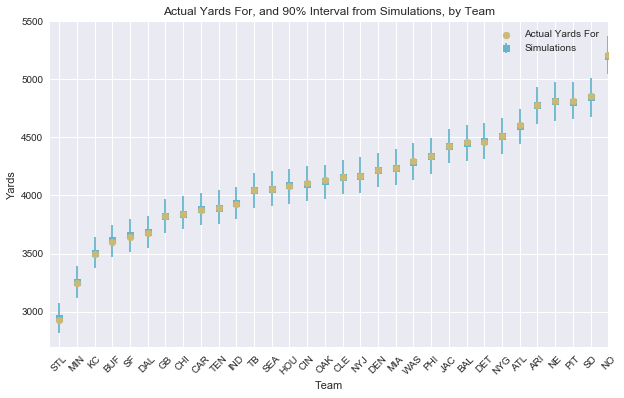

/usr/local/lib/python2.7/site-packages/ipykernel/__main__.py:16: FutureWarning: by argument to sort_index is deprecated, pls use .sort_values(by=...)


In [17]:
df_observed = create_season_table(df)
g = simuls.groupby('team')
season_hdis = pd.DataFrame({'yds_for_lower': g.yf.quantile(.05),
                            'yds_for_median': g.yf.median(),
                            'yds_for_upper': g.yf.quantile(.95),
                            'yds_against_lower': g.ya.quantile(.05),
                            'yds_against_upper': g.ya.quantile(.95),
})

season_hdis = pd.merge(season_hdis, df_observed, left_index=True, right_on='team')
column_order = ['team', 'yds_for_lower', 'yf', 'yds_for_median', 'yds_for_upper',
                'yds_against_lower', 'ya', 'yds_against_upper',]
season_hdis = season_hdis[column_order]
season_hdis['relative_yds_upper'] = season_hdis.yds_for_upper - season_hdis.yds_for_median
season_hdis['relative_yds_lower'] = season_hdis.yds_for_median - season_hdis.yds_for_lower
season_hdis = season_hdis.sort_index(by='yf')
season_hdis = season_hdis.reset_index()
season_hdis['x'] = season_hdis.index + .5
season_hdis

fig, axs = plt.subplots(figsize=(10,6))
axs.scatter(season_hdis.x, season_hdis.yf, c=sns.palettes.color_palette()[4], zorder = 10, label='Actual Yards For')
axs.errorbar(season_hdis.x, season_hdis.yds_for_median,
             yerr=(season_hdis[['relative_yds_lower', 'relative_yds_upper']].values).T,
             fmt='s', c=sns.palettes.color_palette()[5], label='Simulations')
axs.set_title('Actual Yards For, and 90% Interval from Simulations, by Team')
axs.set_xlabel('Team')
axs.set_ylabel('Yards')
axs.set_xlim(0, 20)
axs.legend()
_= axs.set_xticks(season_hdis.index + .5)
_= axs.set_xticklabels(season_hdis['team'].values, rotation=45)